# Dimensionality Reduction by Extracting Principal Components
Wine

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set()

In [8]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
columns = [
    'Class',
    'Alcohol',
    'Malic Acid',
    'Ash',
    'Alcalinity of Ash',
    'Magnesium',
    'Total Phenols',
    'Flavanoids',
    'Nonflavanoid Phenols',
    'Proanthocyanins',
    'Color Intensity',
    'Hue',
    'OD280/OD315 of Diluted Wines',
    'Proline'
]
df = pd.read_csv(url, names=columns)
df.head()


,Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of Diluted Wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
X=df.iloc[:,1:]
X.head()

,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of Diluted Wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [10]:
y=df['Class']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                              test_size=0.2,
                                              random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [13]:
sc.fit(X_train)
X_train_sc=sc.transform(X_train)
X_test_sc=sc.transform(X_test)

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca=PCA(n_components=2)
pca.fit(X_train_sc)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
pca.explained_variance_ratio_

array([0.35900066, 0.18691934])

In [17]:
print(np.round(pca.explained_variance_ratio_,3))

[0.359 0.187]


In [19]:
pd.DataFrame(np.round(pca.components_,3),columns=X.columns).T

,0,1
Alcohol,0.128,0.493
Malic Acid,-0.256,0.190
Ash,-0.022,0.317
Alcalinity of Ash,-0.244,-0.035
Magnesium,0.148,0.262
Total Phenols,0.385,0.096
Flavanoids,0.420,0.015
Nonflavanoid Phenols,-0.299,0.076
Proanthocyanins,0.308,0.074
Color Intensity,-0.119,0.534


In [21]:
pca=PCA(n_components=None)
pca.fit(X_train_sc)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [22]:
pca.transform(X_train_sc)

array([[-1.16602698,  3.61532732,  1.15128454, ..., -0.1121504 ,
         0.07147567, -0.75559169],
       [-3.86261156,  0.48217746,  1.72758428, ...,  0.50457041,
        -0.18288356, -0.122403  ],
       [ 2.28353786, -1.27503318, -0.13167658, ...,  0.48017987,
        -0.45893296,  0.41585049],
       ...,
       [ 4.22339048,  2.40345929, -1.13704654, ..., -0.12930554,
        -0.20588086, -0.04785505],
       [-1.80527275, -1.49091985, -0.08991142, ..., -0.50730299,
        -0.48437788,  0.46676777],
       [-0.07808699, -1.19327925,  1.04439979, ..., -0.24025144,
         0.05180158, -0.28153725]], shape=(142, 13))

In [23]:
print(np.round(pca.explained_variance_ratio_,3))

[0.359 0.187 0.116 0.074 0.067 0.049 0.042 0.027 0.023 0.019 0.017 0.013
 0.008]


In [24]:
np.cumsum(pca.explained_variance_ratio_)

array([0.35900066, 0.54592   , 0.66198557, 0.73570273, 0.80224132,
       0.85078714, 0.89273756, 0.91957678, 0.94305138, 0.96194872,
       0.97910815, 0.99173743, 1.        ])

Text(0, 0.5, 'cummulative explained variance')

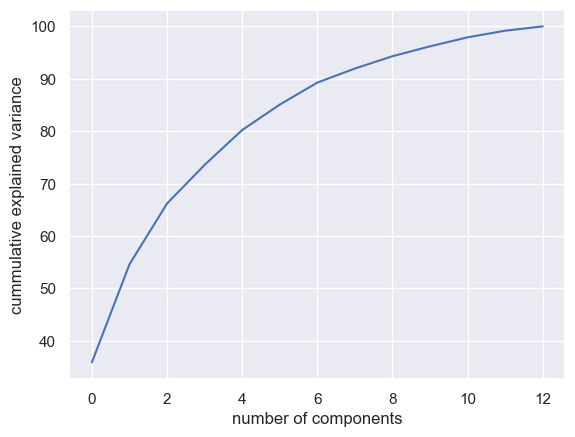

In [26]:
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100.)
plt.xlabel('number of components')
plt.ylabel('cummulative explained variance')

In [27]:
res=pca.transform(X_train_sc)
index_name=['PCA_'+str(k) for k in range(0,len(res))]

In [29]:
df1=pd.DataFrame(res,columns=df.columns[1:],
                 index=index_name)[0:4]
df1.T.sort_values(by='PCA_0')

,PCA_0,PCA_1,PCA_2,PCA_3
Total Phenols,-3.062380,1.016510,-1.004315,-2.754779
Alcalinity of Ash,-1.167179,-0.467086,-1.107830,-1.131270
Alcohol,-1.166027,-3.862612,2.283538,-1.678507
Proline,-0.755592,-0.122403,0.415850,-0.791136
Proanthocyanins,-0.639966,-0.005981,-0.481336,-0.121445
Flavanoids,-0.553745,1.257686,-0.979052,-0.666927
Hue,-0.112150,0.504570,0.480180,-0.319599
OD280/OD315 of Diluted Wines,0.071476,-0.182884,-0.458933,0.045823
Magnesium,0.221634,-0.226540,0.215798,-0.003420
Color Intensity,0.262397,-0.453600,-0.777822,-0.123055
